<a href="https://colab.research.google.com/github/anam-69/deep_learning_practice/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Fraud Detection: Dummy Data Generation, Model Training, and Visualization

## 1. Setup and Dummy Data Generation

To simulate a fraud detection scenario, we'll generate dummy credit card transaction data. This data will include user IDs, timestamps, transaction amounts, and geographical coordinates. We'll also inject some 'fraudulent' transactions to make the dataset more realistic for training a detection model.

### Key Features Generated:
*   `user_id`: Identifier for the transaction user.
*   `timestamp`: Time of the transaction.
*   `amount`: Transaction value.
*   `location_lat`, `location_lon`: Latitude and longitude of the transaction.
*   `is_fraud`: Binary label (0 for legitimate, 1 for fraudulent).

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow import keras
import seaborn as sns # Added this line

# Helper function to calculate Haversine distance between two lat/lon points
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

# Set random seed for reproducibility
np.random.seed(42)

# Number of users and transactions
num_users = 100
transactions_per_user = 50
total_transactions = num_users * transactions_per_user

# Generate dummy data
data = []
user_locations = {}

for user_id in range(num_users):
    # Each user has a 'home' base location
    home_lat = np.random.uniform(30, 45) # Example: US latitude range
    home_lon = np.random.uniform(-120, -70) # Example: US longitude range
    user_locations[user_id] = (home_lat, home_lon)

    current_lat, current_lon = home_lat, home_lon
    current_time = pd.Timestamp('2023-01-01 00:00:00') + pd.to_timedelta(np.random.randint(0, 365), unit='D')

    for i in range(transactions_per_user):
        amount = np.random.normal(50, 20) # Normal transaction amount
        amount = max(5, amount) # Ensure amount is not too low

        # Simulate normal transaction activity (near home or gradual movement)
        if np.random.rand() < 0.99: # Reduced fraud rate to ~1%
            lat = current_lat + np.random.normal(0, 0.1)
            lon = current_lon + np.random.normal(0, 0.1)
            is_fraud = 0
        else:
            # Simulate fraudulent activity: sudden geographic jump or very high amount
            if np.random.rand() < 0.6: # Geographic jump
                lat = np.random.uniform(home_lat - 10, home_lat + 10)
                lon = np.random.uniform(home_lon - 10, home_lon + 10)
                is_fraud = 1
            else: # High amount anomaly
                amount = np.random.normal(500, 100)
                lat = current_lat + np.random.normal(0, 0.05)
                lon = current_lon + np.random.normal(0, 0.05)
                is_fraud = 1

        # Advance time, sometimes quickly for potential velocity fraud
        if is_fraud == 1 and np.random.rand() < 0.5: # Fraudulent transactions sometimes happen quickly
            time_delta = pd.to_timedelta(np.random.randint(1, 60), unit='m')
        else:
            time_delta = pd.to_timedelta(np.random.randint(1, 24 * 60), unit='m')

        current_time += time_delta

        data.append({
            'user_id': user_id,
            'timestamp': current_time,
            'amount': amount,
            'location_lat': lat,
            'location_lon': lon,
            'is_fraud': is_fraud
        })

        if is_fraud == 0: # Only update current location for normal transactions
            current_lat, current_lon = lat, lon

df = pd.DataFrame(data)

# Sort by user and then by timestamp
df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

print("Dummy transaction data generated.")
display(df.head())

Dummy transaction data generated.


,user_id,timestamp,amount,location_lat,location_lon,is_fraud
0,0,2023-04-17 23:17:00,59.477217,35.754947,-72.473747,0
1,0,2023-04-18 03:54:00,31.423438,35.696859,-72.526264,0
2,0,2023-04-18 12:25:00,79.247562,35.850730,-72.524042,0
3,0,2023-04-18 15:35:00,41.444142,35.759928,-72.665272,0
4,0,2023-04-19 02:22:00,54.441578,35.683130,-72.667717,0


### Distribution of Fraudulent vs. Legitimate Transactions

It's important to understand the class distribution of our target variable (`is_fraud`). Fraud detection datasets are typically imbalanced, with a much smaller number of fraudulent transactions compared to legitimate ones. Visualizing this can help in choosing appropriate evaluation metrics and modeling techniques.

/tmp/ipykernel_1283/3236791792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='viridis')


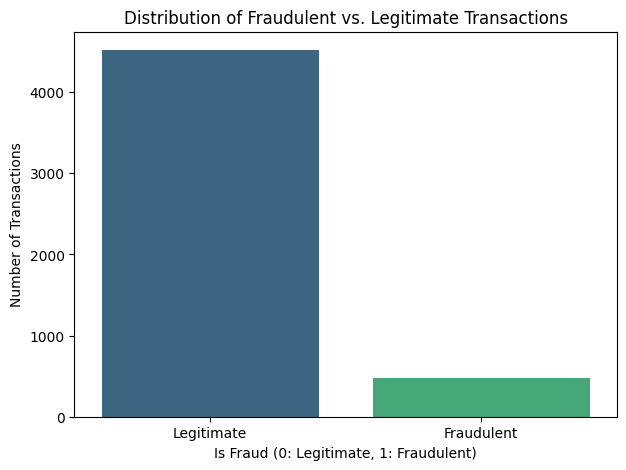

Percentage of legitimate transactions: 90.36%
Percentage of fraudulent transactions: 9.64%


In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(x='is_fraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.show()

fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Percentage of legitimate transactions: {fraud_percentage[0]:.2f}%")
print(f"Percentage of fraudulent transactions: {fraud_percentage[1]:.2f}%")

### Average Transaction Amount: Legitimate vs. Fraudulent

Understanding the average transaction amounts for legitimate and fraudulent transactions can provide valuable insights into the nature of fraudulent activities. Often, fraudulent transactions tend to have significantly different amounts (either much higher or lower, depending on the fraud type) compared to legitimate ones.

Average transaction amount for legitimate vs. fraudulent transactions:
is_fraud
0     50.168131
1    230.767952
Name: amount, dtype: float64


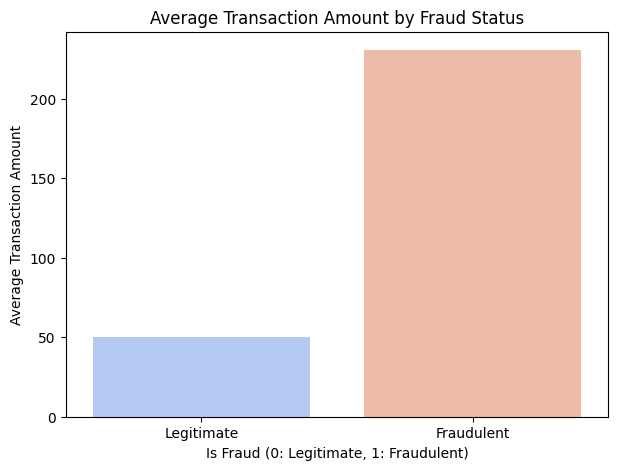

In [36]:
avg_amount_by_fraud = df.groupby('is_fraud')['amount'].mean()
print("Average transaction amount for legitimate vs. fraudulent transactions:")
print(avg_amount_by_fraud)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_amount_by_fraud.index, y=avg_amount_by_fraud.values, hue=avg_amount_by_fraud.index, palette='coolwarm', legend=False)
plt.title('Average Transaction Amount by Fraud Status')
plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Average Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.show()

## 2. Feature Engineering: Velocity, Geographical Patterns, and Behavioral Z-score

To detect fraud, we need to create features that capture unusual patterns in user behavior. These include:

*   **`time_since_last_txn`**: The time difference between the current transaction and the user's previous transaction. A very short time might indicate velocity fraud.
*   **`distance_from_last_txn`**: The geographical distance between the current transaction's location and the user's previous transaction's location. A large distance in a short time is a strong fraud indicator.
*   **`velocity`**: The `distance_from_last_txn` divided by `time_since_last_txn`. High velocity is suspicious.
*   **`amount_zscore_10_txn`**: The z-score of the current transaction amount compared to the user's last 10 transaction amounts. This helps identify unusual spending relative to a user's recent history.

In [38]:
# Ensure data is sorted by user and timestamp for correct calculations
df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Calculate time since last transaction (in seconds)
df['time_since_last_txn'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds().fillna(0)

# Calculate distance from last transaction
df['prev_lat'] = df.groupby('user_id')['location_lat'].shift(1)
df['prev_lon'] = df.groupby('user_id')['location_lon'].shift(1)

df['distance_from_last_txn'] = df.apply(
    lambda row: haversine_distance(
        row['prev_lat'], row['prev_lon'], row['location_lat'], row['location_lon']
    ) if pd.notna(row['prev_lat']) else 0,
    axis=1
)

# Handle the first transaction for each user where previous data is not available
df['distance_from_last_txn'] = df['distance_from_last_txn'].fillna(0)

# Calculate velocity (distance per second). Handle division by zero and infinite values.
df['velocity'] = df['distance_from_last_txn'] / df['time_since_last_txn']
df['velocity'] = df['velocity'].replace([np.inf, -np.inf], np.nan)
df['velocity'] = df['velocity'].fillna(0) # Treat NaN velocities (e.g., 0/0 or inf replaced) as 0

# Calculate rolling z-score for transaction amount (last 10 transactions)
def calculate_rolling_zscore(series):
    # Rolling mean and std for the last 10 transactions
    rolling_mean = series.rolling(window=10, min_periods=1).mean().shift(1)
    rolling_std = series.rolling(window=10, min_periods=1).std().shift(1)
    # Calculate z-score: (current_value - rolling_mean) / rolling_std
    z_score = (series - rolling_mean) / rolling_std
    # Handle cases where rolling_std is 0 (e.g., all previous values are the same) or NaN
    z_score = z_score.replace([np.inf, -np.inf], np.nan).fillna(0)
    return z_score

df['amount_zscore_10_txn'] = df.groupby('user_id')['amount'].transform(calculate_rolling_zscore)

# Drop temporary columns
df = df.drop(columns=['prev_lat', 'prev_lon'])

print("Engineered features added.")
display(df.head())

Engineered features added.


,user_id,timestamp,amount,location_lat,location_lon,is_fraud,time_since_last_txn,distance_from_last_txn,velocity,amount_zscore_10_txn
0,0,2023-04-17 23:17:00,59.477217,35.754947,-72.473747,0,0.0,0.000000,0.000000,0.000000
1,0,2023-04-18 03:54:00,31.423438,35.696859,-72.526264,0,16620.0,8.012116,0.000482,0.000000
2,0,2023-04-18 12:25:00,79.247562,35.850730,-72.524042,0,30660.0,17.110904,0.000558,1.703746
3,0,2023-04-18 15:35:00,41.444142,35.759928,-72.665272,0,11400.0,16.252837,0.001426,-0.635501
4,0,2023-04-19 02:22:00,54.441578,35.683130,-72.667717,0,38820.0,8.542362,0.000220,0.073308


This cell is foundational for our fraud detection project, as it sets up the environment and generates the dummy dataset we'll be working with. Let's break it down:

**Imports**: It starts by importing essential




libraries:

numpy (as np): For numerical operations,









especially in data generation.
pandas (as pd): For data manipulation, particularly creating and working with DataFrames.

matplotlib.pyplot (as plt): For basic plotting.

sklearn.model_selection.train_test_split: To divide data into training and testing sets.

sklearn.preprocessing.StandardScaler: To scale features.

sklearn.metrics: To evaluate model performance (classification_report, roc_auc_score, roc_curve).

tensorflow (as tf) and tensorflow.keras (as keras): For building and training the deep learning model.

seaborn (as sns): For enhanced data visualization.

**haversine_distance function:** This helper function calculates the geographical distance between two points (latitude and longitude) on Earth. This is crucial for engineering location-based features later, especially to detect suspicious travel patterns.

**Random Seed:** np.random.seed(42) is set to ensure that the data generation process is reproducible, meaning you'll get the same 'random' data every time you run this code.

**Dummy Data Generation**: This is the core part, simulating credit card transactions:

It defines num_users (100) and transactions_per_user (50) to create a total of 5000 transactions.

For each user, a 'home' base location (latitude and longitude) and a starting transaction time are randomly generated.

It then iterates through transactions for each user, simulating amount, location_lat, location_lon, and a is_fraud flag.

**Fraud Simulation**: Most transactions are normal (90%). However, 10% are simulated as fraudulent, either by a sudden large geographic jump (location_lat, location_lon far from the user's home or last location) or by a very high transaction amount.

Transaction timestamps are also advanced, sometimes very rapidly for fraudulent transactions to mimic velocity fraud.

The generated data is stored in a list of dictionaries (data).

**DataFrame Creation and Sorting:** Finally, the data list is converted into a pandas DataFrame (df), which is then sorted by user_id and timestamp. This sorting is essential for correctly calculating time-based and location-based features (like time since last transaction or distance from last transaction) for each user.

 In essence, this cell prepares all the raw data we need for our fraud detection model, laying the groundwork for feature engineering and model training.

## 2. Feature Engineering: Velocity and Geographical Patterns

To detect fraud, we need to create features that capture unusual patterns in user behavior. These include:

*   **`time_since_last_txn`**: The time difference between the current transaction and the user's previous transaction. A very short time might indicate velocity fraud.
*   **`distance_from_last_txn`**: The geographical distance between the current transaction's location and the user's previous transaction's location. A large distance in a short time is a strong fraud indicator.
*   **`velocity`**: The `distance_from_last_txn` divided by `time_since_last_txn`. High velocity is suspicious.

## 4. Data Splitting and Scaling

Before training our model, we need to split the data into features (X) and target (y), and then divide it into training and testing sets. Scaling features is crucial for deep learning models to ensure they converge effectively and perform well, especially when features have different ranges.

In [31]:
# Define features (X) and target (y)
# We'll use 'amount', 'time_since_last_txn', 'distance_from_last_txn', and 'velocity'
X = df[['amount', 'time_since_last_txn', 'distance_from_last_txn', 'velocity']].values
y = df['is_fraud'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original X shape: {X.shape}, y shape: {y.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")
print(f"Fraudulent transactions in training set: {np.sum(y_train)} ({np.sum(y_train)/len(y_train)*100:.2f}%)")
print(f"Fraudulent transactions in test set: {np.sum(y_test)} ({np.sum(y_test)/len(y_test)*100:.2f}%)")

Original X shape: (5000, 4), y shape: (5000,)
X_train_scaled shape: (4000, 4), y_train shape: (4000,)
X_test_scaled shape: (1000, 4), y_test shape: (1000,)
Fraudulent transactions in training set: 386 (9.65%)
Fraudulent transactions in test set: 96 (9.60%)


## 5. Build and Train the Deep Learning Model

We will now construct a simple feed-forward neural network using TensorFlow/Keras to classify transactions as legitimate or fraudulent. Given the imbalanced nature of fraud detection datasets, it's often important to consider metrics beyond just accuracy, such as precision, recall, and ROC AUC.

In [28]:
# Build the model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
# Using Adam optimizer and Binary Crossentropy loss for binary classification
# Adding AUC as a metric for better evaluation of imbalanced datasets
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

print("Model built and compiled successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

Model built and compiled successfully.


### Training the Model

We will now train the neural network on the scaled training data. The training process will capture patterns related to fraudulent activities based on the engineered features.

In [39]:
# Train the model

# Calculate class weights for handling imbalanced dataset
neg, pos = np.bincount(y_train)
total = neg + pos
print(f'Total: {total}, Positive: {pos}, Negative: {neg}')

# Scaling by total / (2 * count) ensures that the sum of the weights of all examples equals the sum of the number of examples.
# When using `tf.keras.losses.BinaryCrossentropy(reduction="sum_over_batch_size")`,
# the loss is divided by the batch size. In this case, `class_weight` should be calculated as `total / (2 * count)`
# to maintain the balance such that the effective number of samples for each class is the same.
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f'Weight for class 0: {weight_for_0:.2f}')
print(f'Weight for class 1: {weight_for_1:.2f}')

history = model.fit(
    X_train_scaled, y_train,
    epochs=50, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use a portion of the training data for validation
    class_weight=class_weight, # Added class weights to handle imbalance
    verbose=1 # Show training progress
)

print("Model training complete.")

Total: 4000, Positive: 386, Negative: 3614
Weight for class 0: 0.55
Weight for class 1: 5.18
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9506 - auc: 0.9889 - loss: 0.1355 - val_accuracy: 0.9463 - val_auc: 0.9857 - val_loss: 0.1487
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9484 - auc: 0.9866 - loss: 0.1257 - val_accuracy: 0.9463 - val_auc: 0.9854 - val_loss: 0.1311
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9481 - auc: 0.9909 - loss: 0.1070 - val_accuracy: 0.9463 - val_auc: 0.9791 - val_loss: 0.1266
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9475 - auc: 0.9854 - loss: 0.1329 - val_accuracy: 0.9450 - val_auc: 0.9841 - val_loss: 0.1150
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9481 - auc: 0.9888 - loss: 0.1184 - val_accuracy: 0.9450 - val_auc: 0.9812 - val_loss: 0.1256
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9488 - auc: 0.9890 - loss: 0.1222 - val_a

## 6. Model Evaluation and Visualization

After training, it's crucial to evaluate the model's performance on the unseen test data. We'll look at the loss, accuracy, and AUC score. We'll also visualize the training and validation loss/AUC curves to check for overfitting, and a ROC curve to assess the classifier's performance.

Test Loss: 0.0797
Test Accuracy: 0.9630
Test AUC: 0.9821
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       904
           1       0.98      0.62      0.76        96

    accuracy                           0.96      1000
   macro avg       0.97      0.81      0.87      1000
weighted avg       0.96      0.96      0.96      1000



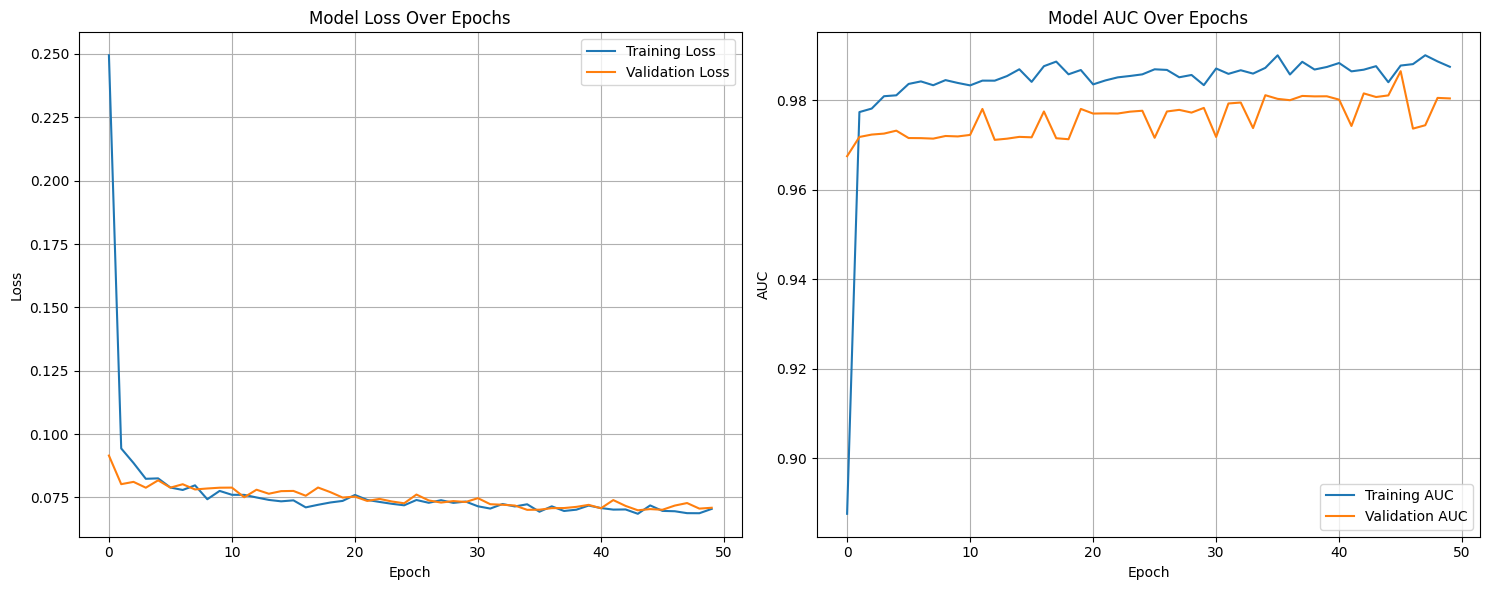

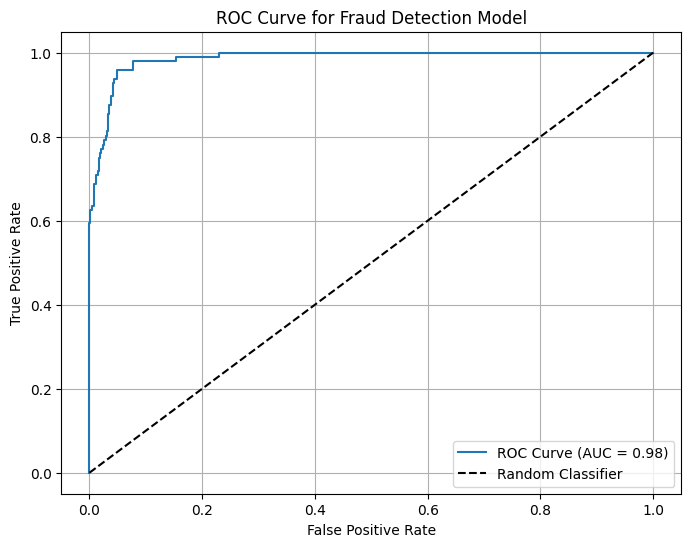

Model evaluation and visualizations complete.


In [30]:
# Evaluate the model on the test set
loss, accuracy, auc_score = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc_score:.4f}")

# Predict probabilities on the test set
y_pred_proba = model.predict(X_test_scaled).ravel()

# Generate classification report and ROC AUC
# We'll use a threshold of 0.5 for binary classification
y_pred_binary = (y_pred_proba > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

# Plot training and validation loss and AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['auc'], label='Training AUC')
ax2.plot(history.history['val_auc'], label='Validation AUC')
ax2.set_title('Model AUC Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve for Fraud Detection Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

print("Model evaluation and visualizations complete.")